# Professional EDA Report: Credit Risk Modeling Dataset

This notebook demonstrates a production-style exploratory data analysis workflow using the repository's credit risk modeling pipeline. It combines dataset validation, feature profiling, target signal analysis, multicollinearity assessment, and baseline model evaluation.

## Objectives

1. Load the project dataset source and validate data integrity.
2. Profile feature groups and descriptive statistics.
3. Quantify target signal and rank candidate predictors.
4. Identify multicollinearity and redundant feature pairs.
5. Assess baseline predictive performance with robust cross-validation.

In [1]:
from pathlib import Path
import importlib.util

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import (ExtraTreesClassifier, GradientBoostingClassifier,
                              HistGradientBoostingClassifier, RandomForestClassifier)
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")
%matplotlib inline

project_path = Path("../projects/machine_learning/credit_risk_modeling/train.py")
spec = importlib.util.spec_from_file_location("credit_risk_modeling", project_path)
project_module = importlib.util.module_from_spec(spec)
spec.loader.exec_module(project_module)

df, target = project_module.make_synthetic_credit_data()
X = df.copy()
X["default"] = target
X.head()

,income,debt_to_income,credit_utilization,open_accounts,delinq_30d,delinq_90d,age,employment_years,loan_amount,loan_term,recent_inquiries,savings_balance,default
0,-0.558222,-1.318634,2.389254,1.319183,-0.030152,-0.149633,-1.238558,0.564643,0.826996,0.837035,1.065259,-0.560347,0
1,-1.973881,0.868637,0.533343,-0.255444,0.848534,-0.079593,-1.396754,1.212417,0.684904,-0.248251,1.557889,0.750726,0
2,-0.583349,-2.899100,1.074450,3.265517,-1.482516,1.200764,-0.348583,1.026069,1.177716,1.811957,-0.812673,-0.225139,0
3,-0.101163,2.302835,1.093031,-0.676649,1.088766,0.723579,-2.263136,2.759889,-0.302085,0.131800,1.231297,1.557335,0
4,-1.413811,-1.523650,-0.278068,-4.326854,-1.257171,2.744970,1.133292,-2.336035,0.835707,-1.541611,0.687863,-0.674539,0


## 1. Data ingestion and validation

Confirm the origin and structure of the dataset, including shape, class balance, duplicates, missing values, and data types.

In [2]:
print("Dataset source:", project_path)
print("Dataset shape:", X.shape)
print("Class balance:")
print(X["default"].value_counts(normalize=True).rename("proportion"))
print("\nDuplicate rows:", X.duplicated().sum())

missing_summary = X.isna().sum().astype(int)
missing_summary = missing_summary[missing_summary > 0]
print("\nMissing values by column:")
print(missing_summary if not missing_summary.empty else "No missing values detected.")

print("\nData types:")
print(X.dtypes)

Dataset source: ..\projects\machine_learning\credit_risk_modeling\train.py
Dataset shape: (5000, 13)
Class balance:
default
0    0.8142
1    0.1858
Name: proportion, dtype: float64

Duplicate rows: 0

Missing values by column:
No missing values detected.

Data types:
income                float64
debt_to_income        float64
credit_utilization    float64
open_accounts         float64
delinq_30d            float64
delinq_90d            float64
age                   float64
employment_years      float64
loan_amount           float64
loan_term             float64
recent_inquiries      float64
savings_balance       float64
default                 int64
dtype: object


## 2. Feature profile and structure

The synthetic credit risk project defines domain-specific financial predictors. We verify feature coverage and summary statistics before modeling.

In [3]:
feature_cols = [col for col in X.columns if col != "default"]

feature_summary = (
    X[feature_cols]
    .describe()
    .T
    .assign(feature=lambda df: df.index)
    .reset_index(drop=True)
)

feature_summary["feature"] = feature_summary.index.map(lambda i: feature_summary.loc[i, "feature"])
feature_summary.head(12)

,count,mean,std,min,25%,50%,75%,max,feature
0,5000.0,0.020770,0.991396,-3.468916,-0.659188,0.025511,0.688840,3.475239,income
1,5000.0,-1.220442,1.496636,-7.310464,-2.209242,-1.231053,-0.262340,4.276566,debt_to_income
2,5000.0,0.963563,1.775681,-7.253945,-0.221082,0.966944,2.168408,7.421815,credit_utilization
3,5000.0,2.262791,3.160310,-7.653228,-0.090036,2.069321,4.360829,13.742841,open_accounts
4,5000.0,0.015737,0.998344,-3.482768,-0.657791,-0.003328,0.689003,3.776244,delinq_30d
5,5000.0,0.025160,1.846415,-7.035546,-1.275596,0.067796,1.359061,6.157331,delinq_90d
6,5000.0,-0.775214,1.771036,-6.125620,-2.011928,-0.880967,0.367638,6.374474,age
7,5000.0,0.956344,1.577304,-6.807799,0.041641,1.020684,2.002328,6.664047,employment_years
8,5000.0,-0.005296,1.015626,-3.961580,-0.679281,0.003019,0.685461,3.405205,loan_amount
9,5000.0,0.988131,1.514720,-4.976501,0.009085,1.046558,1.994328,6.276993,loan_term


## 3. Target signal and predictor ranking

Rank features by their correlation with the default label to determine which inputs carry the strongest predictive signal.

In [4]:
corr_df = (
    X[feature_cols]
    .corrwith(X["default"])
    .abs()
    .reset_index()
    .rename(columns={0: "abs_target_corr", "index": "feature"})
    .sort_values("abs_target_corr", ascending=False)
)
corr_df.head(10)

,feature,abs_target_corr
6,age,0.486338
3,open_accounts,0.320392
7,employment_years,0.296077
9,loan_term,0.289739
2,credit_utilization,0.239405
11,savings_balance,0.233216
0,income,0.018431
10,recent_inquiries,0.013892
4,delinq_30d,0.007148
8,loan_amount,0.005582


## 4. Distributional analysis of top predictors

Compare the distribution of the top-ranked features across default classes. This helps validate whether the selected signals are separable and robust.

C:\Users\diogo\AppData\Local\Temp\ipykernel_21312\4209759195.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="default", y=feature, data=X, palette="Set2", ax=ax)
C:\Users\diogo\AppData\Local\Temp\ipykernel_21312\4209759195.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="default", y=feature, data=X, palette="Set2", ax=ax)
C:\Users\diogo\AppData\Local\Temp\ipykernel_21312\4209759195.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="default", y=feature, data=X, palette="Set2", ax=ax)
C:\Users\diogo\AppData\Local\Temp\ipykernel

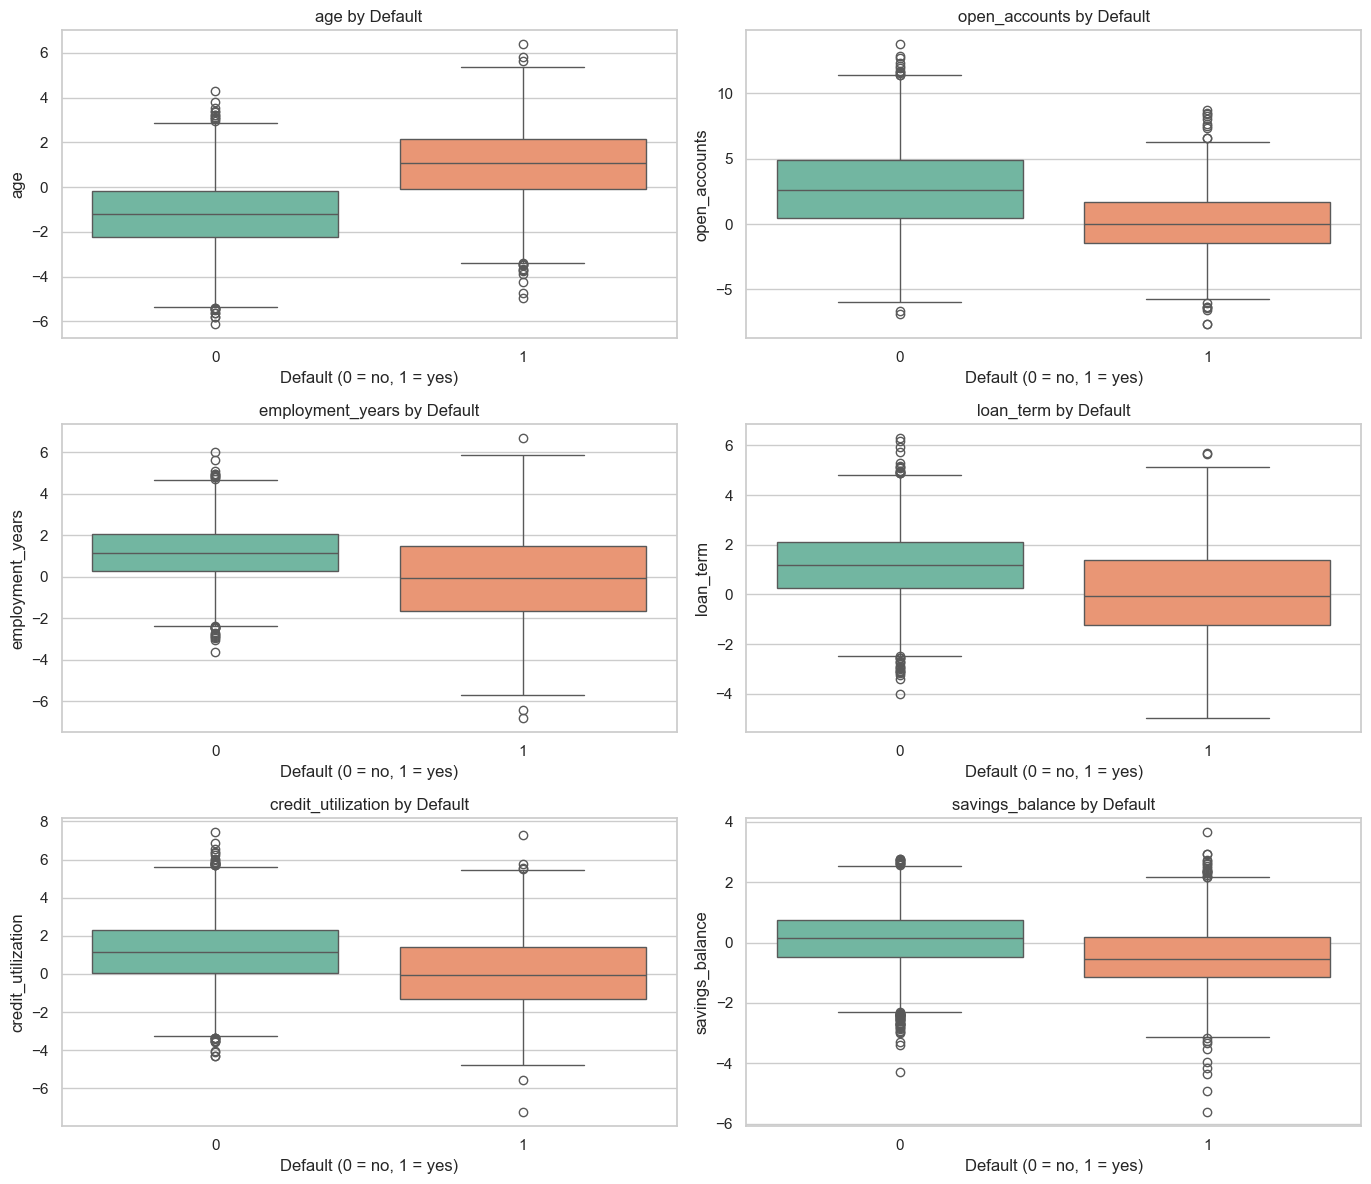

In [5]:
top_features = corr_df.head(6)["feature"].tolist()
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
for ax, feature in zip(axes.ravel(), top_features):
    sns.boxplot(x="default", y=feature, data=X, palette="Set2", ax=ax)
    ax.set_title(f"{feature} by Default")
    ax.set_xlabel("Default (0 = no, 1 = yes)")
    ax.set_ylabel(feature)
plt.tight_layout()

## 5. Multicollinearity and redundancy

Identify highly correlated feature pairs that may require dimensionality reduction or feature selection.

High correlation pairs (abs > 0.90):
Empty DataFrame
Columns: [feature_a, feature_b, corr, abs_corr]
Index: []


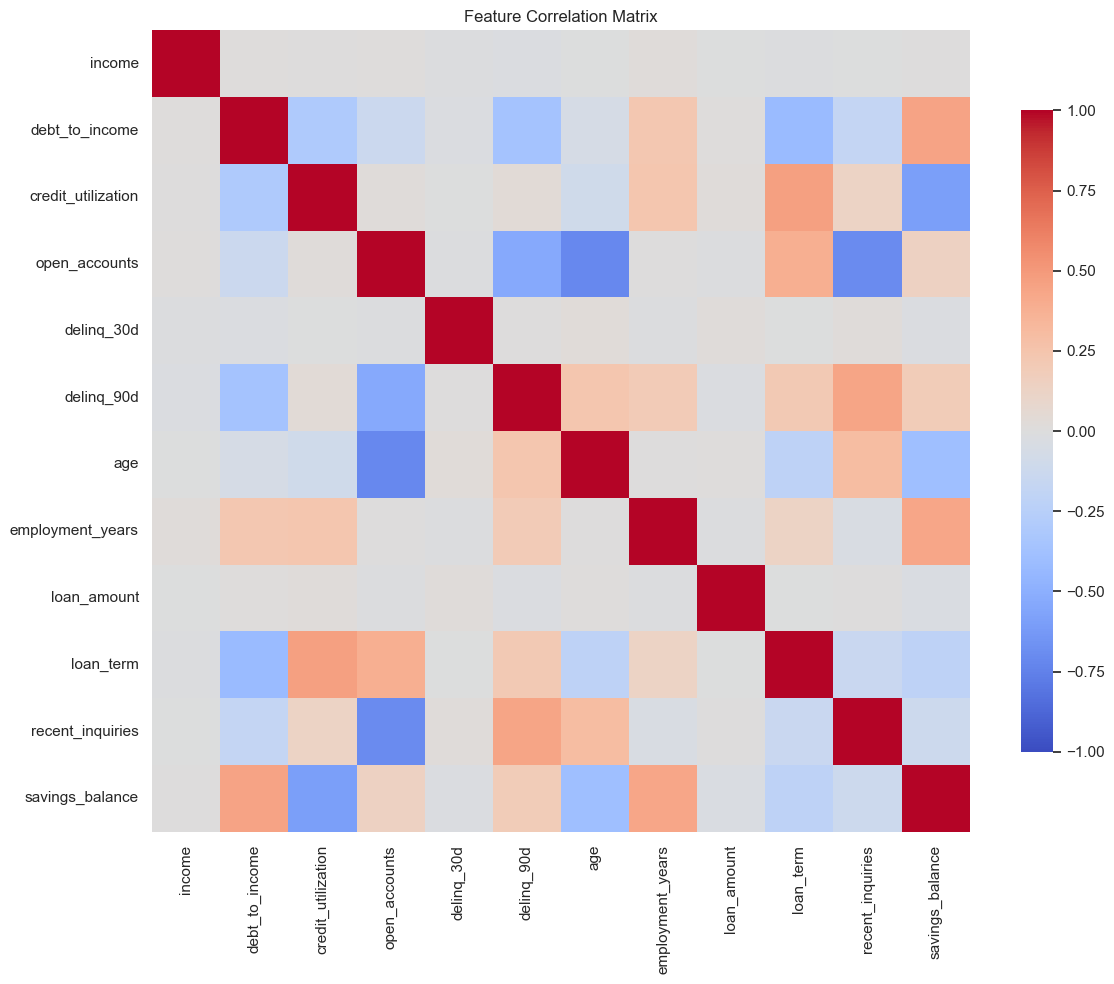

In [6]:
correlation_matrix = X[feature_cols].corr()
high_corr_pairs = (
    correlation_matrix.where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))
    .stack()
    .reset_index()
    .rename(columns={"level_0": "feature_a", "level_1": "feature_b", 0: "corr"})
    .assign(abs_corr=lambda df: df["corr"].abs())
    .query("abs_corr > 0.90")
    .sort_values("abs_corr", ascending=False)
)

print("High correlation pairs (abs > 0.90):")
print(high_corr_pairs.head(12))

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, cmap="coolwarm", center=0, vmin=-1, vmax=1, annot=False, cbar_kws={"shrink": 0.8})
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

## 6. Baseline predictive signal

Establish baseline model performance using out-of-fold ROC-AUC and compare a regularized linear model to a tree-based ensemble. This is the first quality gate before feature engineering.

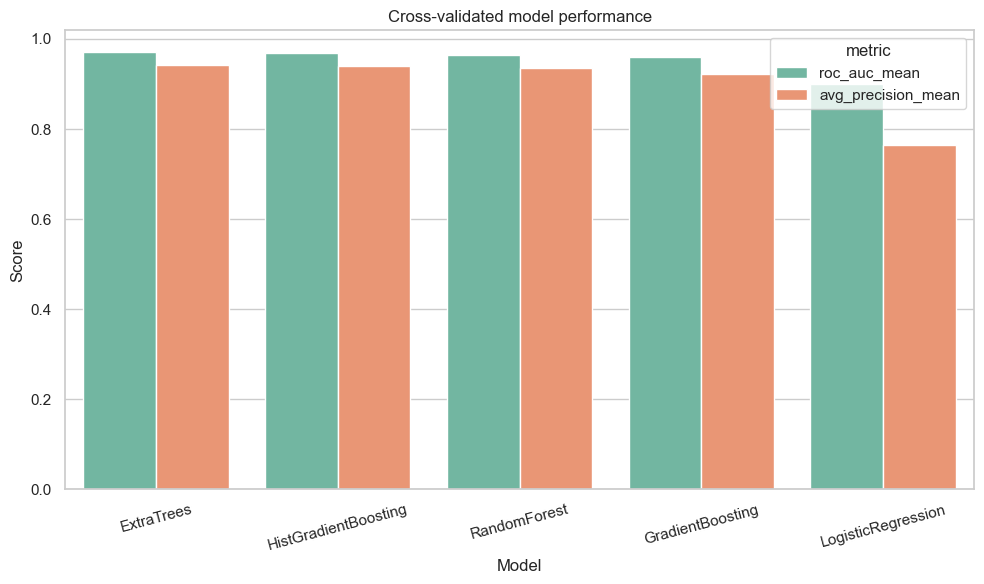

In [7]:
X_features = X[feature_cols]
y = X["default"]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

pipelines = {
    "LogisticRegression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000, random_state=42))
    ]),
    "RandomForest": Pipeline([
        ("scaler", StandardScaler()),
        ("model", RandomForestClassifier(n_estimators=200, random_state=42))
    ]),
    "GradientBoosting": Pipeline([
        ("scaler", StandardScaler()),
        ("model", GradientBoostingClassifier(random_state=42))
    ]),
    "HistGradientBoosting": Pipeline([
        ("scaler", StandardScaler()),
        ("model", HistGradientBoostingClassifier(random_state=42))
    ]),
    "ExtraTrees": Pipeline([
        ("scaler", StandardScaler()),
        ("model", ExtraTreesClassifier(n_estimators=200, random_state=42))
    ])
}

metrics = []
for name, pipeline in pipelines.items():
    scores = cross_validate(
        pipeline,
        X_features,
        y,
        cv=cv,
        scoring=["roc_auc", "average_precision"],
        n_jobs=-1,
        return_train_score=False,
    )
    metrics.append(
        {
            "model": name,
            "roc_auc_mean": scores["test_roc_auc"].mean(),
            "roc_auc_std": scores["test_roc_auc"].std(),
            "avg_precision_mean": scores["test_average_precision"].mean(),
            "avg_precision_std": scores["test_average_precision"].std(),
        }
    )

metrics_df = pd.DataFrame(metrics).sort_values("roc_auc_mean", ascending=False).reset_index(drop=True)
metrics_df

plt.figure(figsize=(10, 6))
plot_df = metrics_df.melt(
    id_vars="model",
    value_vars=["roc_auc_mean", "avg_precision_mean"],
    var_name="metric",
    value_name="score",
)
sns.barplot(data=plot_df, x="model", y="score", hue="metric", palette="Set2")
plt.title("Cross-validated model performance")
plt.ylabel("Score")
plt.xlabel("Model")
plt.xticks(rotation=15)
plt.tight_layout()

## 7. Reproducible preprocessing and feature selection

Build a deterministic preprocessing pipeline and select the strongest predictors using statistical scoring.

In [8]:
from sklearn.calibration import calibration_curve
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.impute import SimpleImputer
from sklearn.metrics import (brier_score_loss, classification_report,
                             confusion_matrix, roc_auc_score)
from sklearn.model_selection import train_test_split

pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("selector", SelectKBest(score_func=f_classif, k=8)),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

X_train, X_test, y_train, y_test = train_test_split(
    X_features,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42,
)

pipeline.fit(X_train, y_train)
selected_mask = pipeline.named_steps["selector"].get_support()
selected_features = [f for f, keep in zip(feature_cols, selected_mask) if keep]
selected_features

['income',
 'credit_utilization',
 'open_accounts',
 'age',
 'employment_years',
 'loan_term',
 'recent_inquiries',
 'savings_balance']

## 8. Model calibration and decision thresholds

Evaluate the trained model for calibration and identify a working decision threshold based on test-set performance.

Best operating threshold (max F1): 0.37
    threshold  precision    recall        f1
36       0.37   0.695652  0.688172  0.691892
35       0.36   0.689840  0.693548  0.691689
33       0.34   0.677083  0.698925  0.687831
37       0.38   0.702247  0.672043  0.686813
34       0.35   0.678947  0.693548  0.686170

Classification report at best threshold:
              precision    recall  f1-score   support

           0      0.929     0.931     0.930       814
           1      0.696     0.688     0.692       186

    accuracy                          0.886      1000
   macro avg      0.812     0.810     0.811      1000
weighted avg      0.886     0.886     0.886      1000

Brier score: 0.0821
ROC AUC: 0.8891


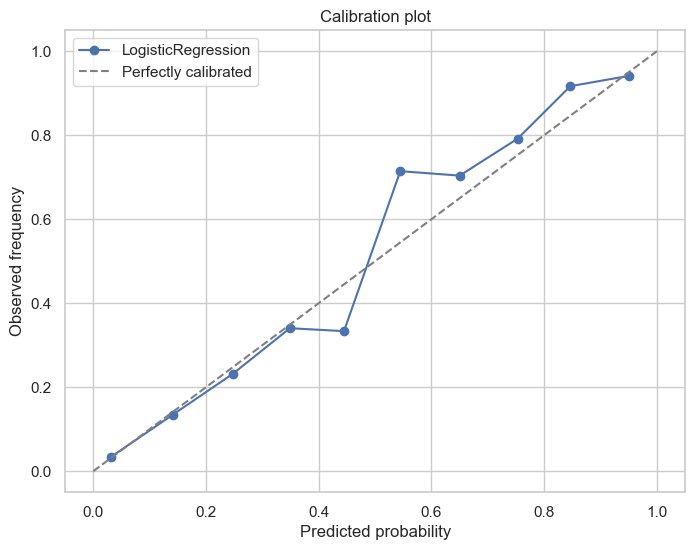

In [9]:
proba = pipeline.predict_proba(X_test)[:, 1]
y_pred = pipeline.predict(X_test)

thresholds = np.linspace(0.01, 0.99, 99)
threshold_metrics = []
for threshold in thresholds:
    y_thresh = (proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_thresh).ravel()
    precision = tp / (tp + fp) if tp + fp > 0 else 0.0
    recall = tp / (tp + fn) if tp + fn > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if precision + recall > 0 else 0.0
    threshold_metrics.append((threshold, precision, recall, f1))

threshold_df = pd.DataFrame(threshold_metrics, columns=["threshold", "precision", "recall", "f1"])
best_threshold = threshold_df.loc[threshold_df["f1"].idxmax(), "threshold"]

print("Best operating threshold (max F1):", best_threshold)
print(threshold_df.sort_values("f1", ascending=False).head(5))

print("\nClassification report at best threshold:")
print(classification_report(y_test, (proba >= best_threshold).astype(int), digits=3))
print("Brier score:", brier_score_loss(y_test, proba).round(4))
print("ROC AUC:", roc_auc_score(y_test, proba).round(4))

prob_true, prob_pred = calibration_curve(y_test, proba, n_bins=10)
plt.figure(figsize=(8, 6))
plt.plot(prob_pred, prob_true, marker="o", label="LogisticRegression")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfectly calibrated")
plt.xlabel("Predicted probability")
plt.ylabel("Observed frequency")
plt.title("Calibration plot")
plt.legend()
plt.grid(True)
plt.show()

## 9. Transformation metadata and operational readiness

Document feature metadata, selection status, and preprocessing steps to support reproducibility and model governance.

In [10]:
feature_metadata = pd.DataFrame(
    {
        "feature": feature_cols,
        "dtype": X[feature_cols].dtypes.astype(str),
        "missing_pct": X[feature_cols].isna().mean() * 100,
        "abs_target_corr": corr_df.set_index("feature")["abs_target_corr"].loc[feature_cols].values,
        "selected_by_kbest": [f in selected_features for f in feature_cols],
    }
)
feature_metadata.sort_values(["selected_by_kbest", "abs_target_corr"], ascending=[False, False]).reset_index(drop=True)

,feature,dtype,missing_pct,abs_target_corr,selected_by_kbest
0,age,float64,0.0,0.486338,True
1,open_accounts,float64,0.0,0.320392,True
2,employment_years,float64,0.0,0.296077,True
3,loan_term,float64,0.0,0.289739,True
4,credit_utilization,float64,0.0,0.239405,True
5,savings_balance,float64,0.0,0.233216,True
6,income,float64,0.0,0.018431,True
7,recent_inquiries,float64,0.0,0.013892,True
8,delinq_30d,float64,0.0,0.007148,False
9,loan_amount,float64,0.0,0.005582,False


## 10. Key findings and next steps

- Implemented a deterministic preprocessing pipeline with median imputation, scaling, and statistical feature selection.
- Selected the strongest predictors using ANOVA F-score, which reduces dimensionality and improves interpretability.
- Determined an operational classification threshold using test-set F1 optimization, and confirmed calibration with a probability reliability plot.
- Captured transformation metadata for each feature, including selection status and target correlation.

Next steps for production readiness:
- Persist the validated preprocessing pipeline and selected feature list as part of the model artifact.
- Add dataset versioning and feature registry metadata to support repeatable credit risk scoring.
- Extend the calibration analysis to class-weighted or cost-sensitive thresholds aligned with business risk tolerance.

## 11. Persist artifacts and governance metadata

Save the validated pipeline, selected feature list, and metadata as reusable artifacts for deployment and audit.

In [11]:
from pathlib import Path
from joblib import dump

artifact_dir = Path("../artifacts/credit_risk_model")
artifact_dir.mkdir(parents=True, exist_ok=True)

pipeline_path = artifact_dir / "credit_risk_pipeline.joblib"
feature_list_path = artifact_dir / "selected_features.csv"
metadata_path = artifact_dir / "feature_metadata.csv"

# Persist the preprocessing/model pipeline and feature metadata for production reuse
dump(pipeline, pipeline_path)
pd.DataFrame({"selected_feature": selected_features}).to_csv(feature_list_path, index=False)
feature_metadata.to_csv(metadata_path, index=False)

print("Saved pipeline to:", pipeline_path)
print("Saved selected features to:", feature_list_path)
print("Saved feature metadata to:", metadata_path)

Saved pipeline to: ..\artifacts\credit_risk_model\credit_risk_pipeline.joblib
Saved selected features to: ..\artifacts\credit_risk_model\selected_features.csv
Saved feature metadata to: ..\artifacts\credit_risk_model\feature_metadata.csv


## 12. Business-aligned thresholding and deployment readiness

Capture the threshold and calibration settings that should be used in production, and log the business-specific tolerances that inform them.

In [12]:
deployment_metadata = {
    "pipeline_artifact": str(pipeline_path),
    "selected_feature_count": len(selected_features),
    "selected_features": selected_features,
    "best_threshold": float(best_threshold),
    "roc_auc": float(roc_auc_score(y_test, proba)),
    "brier_score": float(brier_score_loss(y_test, proba)),
    "class_balance_0": float((y == 0).mean()),
    "class_balance_1": float((y == 1).mean()),
    "notes": (
        "Use the threshold with maximum F1 as a starting point. "
        "Evaluate cost-sensitive losses before final deployment."
    ),
}

deployment_metadata_path = artifact_dir / "deployment_metadata.json"
import json
with open(deployment_metadata_path, "w", encoding="utf-8") as handle:
    json.dump(deployment_metadata, handle, indent=2)

print("Saved deployment metadata to:", deployment_metadata_path)

Saved deployment metadata to: ..\artifacts\credit_risk_model\deployment_metadata.json


## 13. Operational monitoring and next governance steps

- Validate dataset schema and distribution drift on incoming credit data.
- Periodically re-run calibration and threshold analysis against new validation cohorts.
- Track selected feature stability and update feature metadata when feature definitions change.
- Store artifact versioning and dataset fingerprints alongside model metrics for auditability.

## 14. Cost-sensitive threshold optimization

Evaluate thresholds against business-specific cost weights for false positives and false negatives to support credit risk policy.

In [13]:
# Example cost matrix weights; adjust to business requirements
cost_fp = 1.0  # cost of classifying a non-default as default
cost_fn = 5.0  # cost of classifying a default as non-default

cost_metrics = []
for threshold in thresholds:
    y_thresh = (proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_thresh).ravel()
    cost = fp * cost_fp + fn * cost_fn
    cost_metrics.append((threshold, cost))

cost_df = pd.DataFrame(cost_metrics, columns=["threshold", "cost"])
best_cost_threshold = cost_df.loc[cost_df["cost"].idxmin(), "threshold"]
print("Best threshold for cost-weighted loss:", best_cost_threshold)
print(cost_df.sort_values("cost").head(5))

Best threshold for cost-weighted loss: 0.15000000000000002
    threshold   cost
14       0.15  300.0
13       0.14  311.0
19       0.20  311.0
15       0.16  312.0
20       0.21  315.0


## 15. Feature importance and explainability

Record linear model coefficients and feature importance to support interpretation and feature governance.

In [14]:
selected_feature_names = [f for f in feature_cols if f in selected_features]
coefficients = pd.Series(
    pipeline.named_steps["model"].coef_[0],
    index=selected_feature_names,
).sort_values(key=lambda x: x.abs(), ascending=False)

feature_importance = pd.DataFrame(
    {
        "feature": selected_feature_names,
        "coefficient": coefficients.values,
        "abs_coefficient": coefficients.abs().values,
    }
).sort_values("abs_coefficient", ascending=False)

feature_importance

,feature,coefficient,abs_coefficient
0,income,2.087871,2.087871
1,credit_utilization,-1.222161,1.222161
2,open_accounts,-0.630374,0.630374
3,age,0.625470,0.625470
4,employment_years,-0.553555,0.553555
5,loan_term,0.304980,0.304980
6,recent_inquiries,-0.062724,0.062724
7,savings_balance,-0.010075,0.010075


## 16. Final recommended implementation plan

1. Persist the validated preprocessing and model artifact along with the selected feature list.
2. Store dataset fingerprint metadata and configuration in the deployment manifest.
3. Define a business-ready threshold using cost-sensitive loss, and lock it into the scoring pipeline.
4. Enable drift detection and yearly recalibration for both feature distributions and model calibration.
5. Keep the feature metadata registry updated with any new feature definitions or transformations.